In [1]:
import pandas as pd
import numpy as np
import itertools
import statsmodels.api as sm
import matplotlib.pyplot as plt

### Lab 6

#### Task 6.5.1
Here we apply the best subset selection approach to the Hitters data. We
wish to predict a baseball player’s Salary on the basis of various statistics
associated with performance in the previous year

First of all, we note that the Salary variable is missing for some of the
players.

In [7]:
hitters = pd.read_csv("data/Hitters.csv")
print(f"Lost salaries {hitters["Salary"].isna().sum()}")

Lost salaries 59


Hence we see that Salary is missing for 59 players. Remove them

In [8]:
hitters = hitters.dropna()
print(f"The data set size: {hitters.shape}\n")

The data set size: (263, 20)



In [9]:
hitters.info()

<class 'pandas.core.frame.DataFrame'>
Index: 263 entries, 1 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AtBat      263 non-null    int64  
 1   Hits       263 non-null    int64  
 2   HmRun      263 non-null    int64  
 3   Runs       263 non-null    int64  
 4   RBI        263 non-null    int64  
 5   Walks      263 non-null    int64  
 6   Years      263 non-null    int64  
 7   CAtBat     263 non-null    int64  
 8   CHits      263 non-null    int64  
 9   CHmRun     263 non-null    int64  
 10  CRuns      263 non-null    int64  
 11  CRBI       263 non-null    int64  
 12  CWalks     263 non-null    int64  
 13  League     263 non-null    object 
 14  Division   263 non-null    object 
 15  PutOuts    263 non-null    int64  
 16  Assists    263 non-null    int64  
 17  Errors     263 non-null    int64  
 18  Salary     263 non-null    float64
 19  NewLeague  263 non-null    object 
dtypes: float64(1), 

In [10]:
hitters = pd.get_dummies(hitters, columns=["League", "Division", "NewLeague"], drop_first=True, dtype=int)

In [12]:
hitters.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary,League_N,Division_W,NewLeague_N
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,632,43,10,475.0,1,1,1
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,880,82,14,480.0,0,1,0
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,200,11,3,500.0,1,0,1
4,321,87,10,39,42,30,2,396,101,12,48,46,33,805,40,4,91.5,1,0,1
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,282,421,25,750.0,0,1,0


In [13]:
X = hitters.drop(columns=["Salary"])
X = sm.add_constant(X)
y = hitters["Salary"]

In [14]:
# the function for estimating one certain combination of variables
def process_subset(feature_set):
    model = sm.OLS(y, X[list(feature_set)]).fit()
    RSS = model.ssr
    return {"model": model, "RSS": RSS, "features": feature_set}


# the function for searching best model within all combinations k
def get_best_of_k(k):
    # gether all features without const
    features_without_const = [col for col in X.columns if col != 'const']
    
    results = []
    # trying all possible combinations k size
    for combo in itertools.combinations(features_without_const, k):
        # adding const in every single model
        combo_with_const = list(combo) + ['const']
        results.append(process_subset(combo_with_const))

    # return the model with the minimum RSS
    df_results = pd.DataFrame(results)
    best_model = df_results.loc[df_results['RSS'].idxmin()]
    return best_model

In [17]:
hitters.shape

(263, 20)

In [18]:
# Start loop
best_models = {}
for k in range(1, 20):
    best_models[k] = get_best_of_k(k)
    print(f"The model with size k={k} is done.")

print("\n--- All models are computed ---")

The model with size k=1 is done.
The model with size k=2 is done.
The model with size k=3 is done.
The model with size k=4 is done.
The model with size k=5 is done.
The model with size k=6 is done.
The model with size k=7 is done.
The model with size k=8 is done.
The model with size k=9 is done.
The model with size k=10 is done.
The model with size k=11 is done.
The model with size k=12 is done.
The model with size k=13 is done.
The model with size k=14 is done.
The model with size k=15 is done.
The model with size k=16 is done.
The model with size k=17 is done.
The model with size k=18 is done.
The model with size k=19 is done.

--- All models are computed ---


In [19]:
summary_data = []

full_model = best_models[19]["model"]
sig2 = full_model.ssr / full_model.df_resid
n = len(y)

for k, row in best_models.items():
    model = row["model"]
    d = len(row['features'])
    cp = (row['RSS'] / sig2) - n + 2 * d
    
    summary_data.append({
        "k": k,
        "RSS": row['RSS'],
        "R2": model.rsquared,
        "Adj_R2": model.rsquared_adj,
        "Cp": cp,
        "BIC": model.bic
    })

df_summary = pd.DataFrame(summary_data)

# searching the best points
best_adj_r2 = df_summary.loc[df_summary["Adj_R2"].idxmax()]
best_cp = df_summary.loc[df_summary["Cp"].idxmin()]
best_bic = df_summary.loc[df_summary["BIC"].idxmin()]

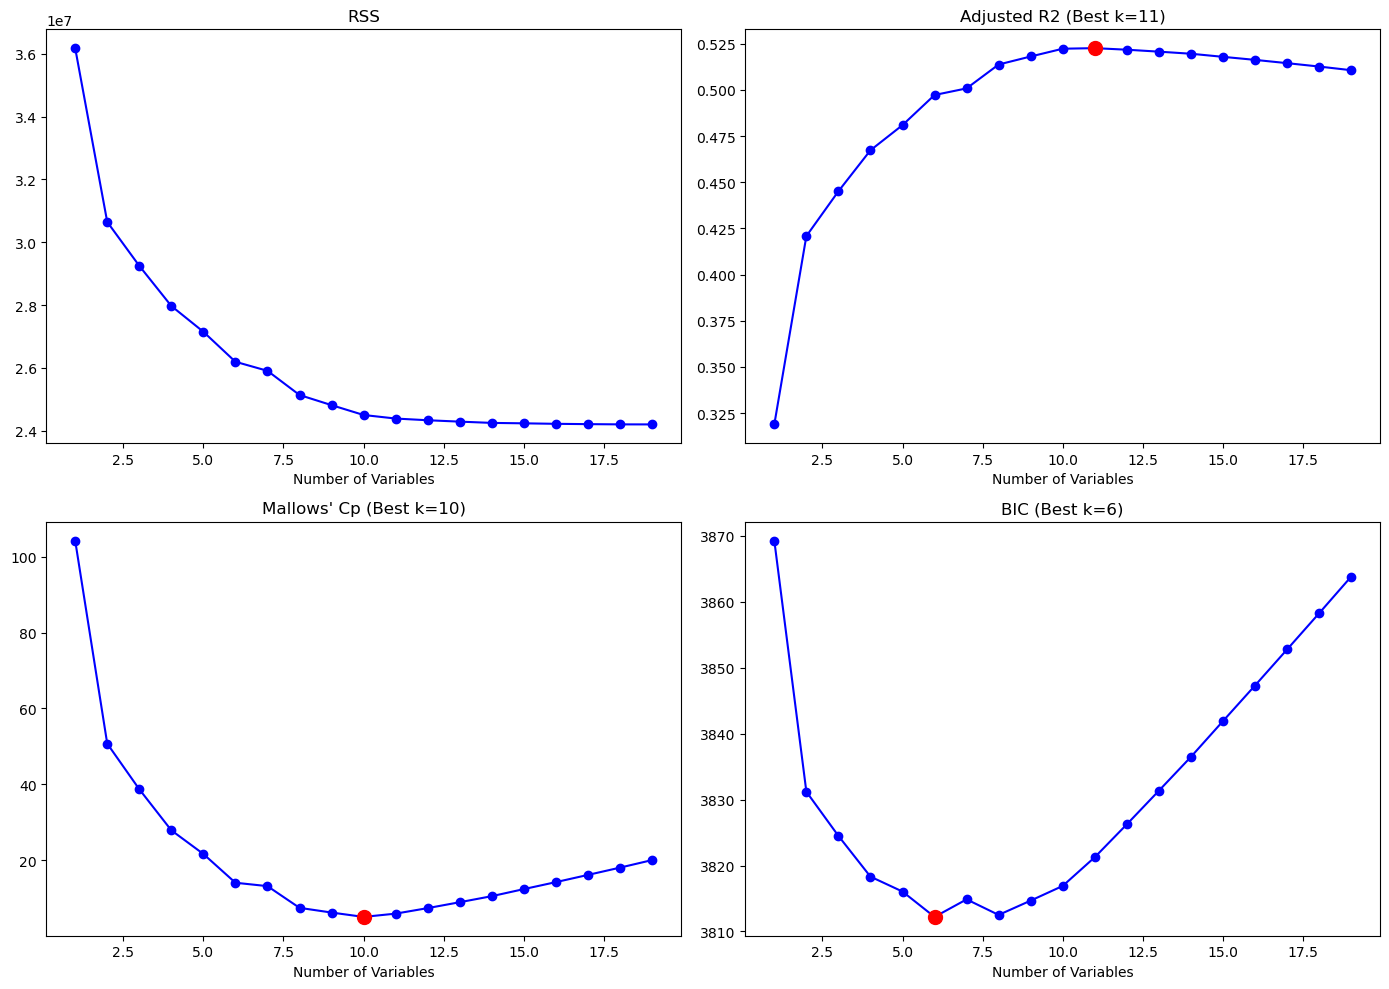

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. RSS
axes[0, 0].plot(df_summary["k"], df_summary["RSS"], marker="o", color="b")
axes[0, 0].set_title("RSS")
axes[0, 0].set_xlabel("Number of Variables")

# 2. Adjusted R2
axes[0, 1].plot(df_summary["k"], df_summary["Adj_R2"], marker="o", color="b")
axes[0, 1].scatter(best_adj_r2["k"], best_adj_r2["Adj_R2"], color="red", s=100, zorder=5)
axes[0, 1].set_title(f"Adjusted R2 (Best k={int(best_adj_r2['k'])})")
axes[0, 1].set_xlabel("Number of Variables")

# 3. Cp
axes[1, 0].plot(df_summary["k"], df_summary["Cp"], marker="o", color="b")
axes[1, 0].scatter(best_cp["k"], best_cp["Cp"], color="red", s=100, zorder=5)
axes[1, 0].set_title(f"Mallows' Cp (Best k={int(best_cp['k'])})")
axes[1, 0].set_xlabel("Number of Variables")

# 4. BIC
axes[1, 1].plot(df_summary["k"], df_summary["BIC"], marker="o", color="b")
axes[1, 1].scatter(best_bic["k"], best_bic["BIC"], color="red", s=100, zorder=5)
axes[1, 1].set_title(f"BIC (Best k={int(best_bic['k'])})")
axes[1, 1].set_xlabel("Number of Variables")

plt.tight_layout()
plt.show()

In [24]:
print("--- Coefficients best 6-variables model (BIC) ---")
best_6_model = best_models[6]["model"]
print(best_6_model.params)

--- Coefficients best 6-variables model (BIC) ---
AtBat          -1.868589
Hits            7.604398
Walks           3.697647
CRBI            0.643017
PutOuts         0.264308
Division_W   -122.951534
const          91.511798
dtype: float64


Based on computed and lotted information we can draw next conslusions:
- The more variables we add to the model the more $R^2$ we get and the less RSS
- The only one measure that should be maximum for choosing is adjusted $R^2$. Here we cann see that when k=11 then adjusted $R^2$ has maximum value
- The $C_p$ measure has chosen the model with 10 k. It means that the measure does not have big benalty for amount of features
- In contrast, the BIC meassure include $log$ penalty for using bug amount of features, therefore in this certain measure the best value was riached when k=6

#### Task 6.5.2 Forward and Backward Stepwise Selection

In [32]:
# --- FORWARD STEPWISE SELECTION ---
def forward_selection(X, y, nvmax=19):
    features_without_const = [col for col in X.columns if col != "const"]
    current_features = ["const"]
    models_forward = {}
    
    for k in range(1, nvmax + 1):
        remaining_features = [f for f in features_without_const if f not in current_features]
        best_rss = np.inf
        best_feature = None
        best_model = None

        # looking for one best feature on order to add
        for feature in remaining_features:
            test_features = current_features + [feature]
            model = sm.OLS(y, X[test_features]).fit()
            if model.ssr < best_rss:
                best_rss = model.ssr
                best_feature = feature
                best_model = model
                
        current_features.append(best_feature)
        models_forward[k] = {"model": best_model, "features": list(current_features)}
    return models_forward


# --- BACKWARD STEPWISE SELECTION ---
def backward_selection(X, y, nvmax=19):
    features_without_const = [col for col in X.columns if col != "const"]
    current_features = features_without_const + ["const"]
    models_backward = {}
    
    # start with the full model
    full_model = sm.OLS(y, X[current_features]).fit()
    models_backward[19] = {"model": full_model, "features": list(current_features)}
    
    for k in range(18, 0, -1):
        features_to_test = [f for f in current_features if f != "const"]
        best_rss = np.inf
        feature_to_remove = None
        best_model = None

        # looking for the worst model in order to get rid of it
        for feature in features_to_test:
            test_features = [f for f in current_features if f != feature]
            model = sm.OLS(y, X[test_features]).fit()
            if model.ssr < best_rss:
                best_rss = model.ssr
                feature_to_remove = feature
                best_model = model
                
        current_features.remove(feature_to_remove)
        models_backward[k] = {"model": best_model, "features": list(current_features)}
    return models_backward


models_fwd = forward_selection(X, y, nvmax=19)
models_bwd = backward_selection(X, y, nvmax=19)

print("--- Comparing the models k=7 ---")
print("\n[Forward Selection k=7]:")
print(models_fwd[7]['model'].params)

print("\n[Backward Selection k=7]:")
print(models_bwd[7]['model'].params)

print("\n[Best Subset Selection models k=7]")
best_7_model = best_models[7]["model"]
print(best_7_model.params)

--- Comparing the models k=7 ---

[Forward Selection k=7]:
const         109.787306
CRBI            0.853762
Hits            7.449877
PutOuts         0.253340
Division_W   -127.122393
AtBat          -1.958885
Walks           4.913140
CWalks         -0.305307
dtype: float64

[Backward Selection k=7]:
AtBat          -1.976284
Hits            6.757491
Walks           6.055869
CRuns           1.129309
CWalks         -0.716335
PutOuts         0.302885
Division_W   -116.169217
const         105.648749
dtype: float64

[Best Subset Selection models k=7]
Hits            1.283351
Walks           3.227426
CAtBat         -0.375235
CHits           1.495707
CHmRun          1.442054
PutOuts         0.236681
Division_W   -129.986643
const          79.450947
dtype: float64


As we can see all three approaches have chosen different features. The difference in methods is clearly seen

#### Task 6.5.3 Choosing Among Models Using the Validation Set Approach and Cross-Validation

We just saw that it is possible to choose among a set of models of different
sizes using Cp, BIC, and adjusted R2. We will now consider how to do this
using the validation set and cross-validation approaches.
In order for these approaches to yield accurate estimates of the test
error, we must use only the training observations to perform all aspects of
model-fitting—including variable selection. Therefore, the determination of
which model of a given size is best must be made using only the training
observations. This point is subtle but important. If the full data set is used
to perform the best subset selection step, the validation set errors and
cross-validation errors that we obtain will not be accurate estimates of the
test error.

In [33]:
from sklearn.metrics import mean_squared_error

In [34]:
X = sm.add_constant(hitters.drop(columns=["Salary"])).astype(float)
y = hitters["Salary"].astype(float)

In [37]:
np.random.seed(1)
train_mask = np.random.choice([True, False], size=len(hitters), p=[0.5, 0.5])

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[~train_mask], y[~train_mask]

features_list = [col for col in X.columns if col != "const"]

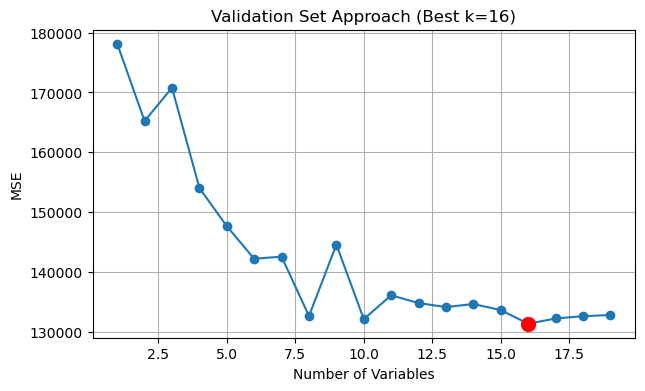

--- Best coefficient using full data set k=16 ---
AtBat          -1.970974
Hits            7.435772
HmRun           4.112045
Runs           -2.223676
RBI            -0.988085
Walks           6.171224
CAtBat         -0.189278
CHits           0.191540
CRuns           1.437738
CRBI            0.744465
CWalks         -0.803505
PutOuts         0.283100
Assists         0.378577
Errors         -3.230934
League_N       42.925267
Division_W   -115.845735
const         148.583625
dtype: float64


In [41]:
# the functions for searching the best model k size on train data
def get_best_subset_on_train(X_tr, y_tr, k):
    results = []
    for combo in itertools.combinations(features_list, k):
        combo_with_const = list(combo) + ["const"]
        model = sm.OLS(y_tr, X_tr[combo_with_const]).fit()
        results.append({"RSS": model.ssr, "features": combo_with_const})
    return pd.DataFrame(results).loc[pd.DataFrame(results)['RSS'].idxmin()]["features"]


val_errors = []
best_features_per_k = {}

for k in range(1, 20):

    best_features = get_best_subset_on_train(X_train, y_train, k)
    best_features_per_k[k] = best_features
    
    model_train = sm.OLS(y_train, X_train[best_features]).fit()
    
    preds = model_train.predict(X_val[best_features])
    val_errors.append(mean_squared_error(y_val, preds))

best_k_val = np.argmin(val_errors) + 1

plt.figure(figsize=(7, 4))
plt.plot(range(1, 20), val_errors, marker='o')
plt.scatter(best_k_val, val_errors[best_k_val-1], color='red', s=100, zorder=5)
plt.title(f"Validation Set Approach (Best k={best_k_val})")
plt.xlabel("Number of Variables")
plt.ylabel("MSE")
plt.grid(True)
plt.show()

print(f"--- Best coefficient using full data set k={best_k_val} ---")
full_features = get_best_subset_on_train(X, y, best_k_val)
final_model_val = sm.OLS(y, X[full_features]).fit()
print(final_model_val.params)

In [42]:
from sklearn.model_selection import KFold

In [ ]:
kf = KFold(n_splits=10, shuffle=True, random_state=1)
cv_errors_matrix = np.zeros((10, 19))

fold_idx = 0
for train_idx, test_idx in kf.split(X):
    X_tr_fold, y_tr_fold = X.iloc[train_idx], y.iloc[train_idx]
    X_te_fold, y_te_fold = X.iloc[test_idx], y.iloc[test_idx]
    
    for k in range(1, 20):

        best_features = get_best_subset_on_train(X_tr_fold, y_tr_fold, k)
        
        model_fold = sm.OLS(y_tr_fold, X_tr_fold[best_features]).fit()
        
        preds_fold = model_fold.predict(X_te_fold[best_features])
        cv_errors_matrix[fold_idx, k-1] = mean_squared_error(y_te_fold, preds_fold)
        
    fold_idx += 1


mean_cv_errors = cv_errors_matrix.mean(axis=0)
best_k_cv = np.argmin(mean_cv_errors) + 1

plt.figure(figsize=(7, 4))
plt.plot(range(1, 20), mean_cv_errors, marker='o', color='purple')
plt.scatter(best_k_cv, mean_cv_errors[best_k_cv-1], color='red', s=100, zorder=5)
plt.title(f"10-Fold Cross-Validation (Best k={best_k_cv})")
plt.xlabel("Number of Variables")
plt.ylabel("Mean CV MSE")
plt.grid(True)
plt.show()

print(f"--- Best coefficient using full data set k={best_k_cv} ---")
full_features_cv = get_best_subset_on_train(X, y, best_k_cv)
final_model_cv = sm.OLS(y, X[full_features_cv]).fit()
print(final_model_cv.params)

Validation set approach has chosen k=16

#### Task 6.6.1 Ridge Regression

In [44]:
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler

In [46]:
hitters = pd.read_csv("data/Hitters.csv").dropna()
hitters = pd.get_dummies(hitters, columns=["League", "Division", "NewLeague"], drop_first=True, dtype=int)

X = hitters.drop(columns=["Salary"]).astype(float)
y = hitters["Salary"].astype(float)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

lambdas = 10**np.linspace(10, -2, 100)

coefs = []

for l in lambdas:
    ridge = Ridge(alpha=l)
    ridge.fit(X_scaled_df, y)
    coefs.append(ridge.coef_)

# check dimention of matrix
print(f"The dimention coefficients matrix: {np.array(coefs).shape}")

large_lambda = lambdas[40]
ridge_large = Ridge(alpha=large_lambda).fit(X_scaled_df, y)
l2_norm_large = np.sqrt(np.sum(ridge_large.coef_**2))

print(f"\nIn case large Lambda = {large_lambda:.2f}:")
print(f"L2 norm coefficients (without intercept): {l2_norm_large:.4f}")


small_lambda = lambdas[80]
ridge_small = Ridge(alpha=small_lambda).fit(X_scaled_df, y)
l2_norm_small = np.sqrt(np.sum(ridge_small.coef_**2))

print(f"\nIn case small Lambda = {small_lambda:.2f}:")
print(f"L2 norm coefficients (without intercept): {l2_norm_small:.4f}")

The dimention coefficients matrix: (100, 19)

In case large Lambda = 141747.42:
L2 norm coefficients (without intercept): 1.4428

In case small Lambda = 2.01:
L2 norm coefficients (without intercept): 557.5078


A large value of $\lambda$ leads to an increase in test MSE. When we restrict the model too heavily, the weights cannot reach their optimal values. The model fails to capture underlying patterns, which increases bias and leads to underfitting

In [51]:
# splitting test/train
np.random.seed(1)
train_indices = np.random.choice(X.index, size=len(X)//2, replace=False)
test_indices = X.index.difference(train_indices)

scaler_split = StandardScaler()
X_train_scaled = scaler_split.fit_transform(X.loc[train_indices])
X_test_scaled = scaler_split.transform(X.loc[test_indices])

y_train = y.loc[train_indices]
y_test = y.loc[test_indices]

# the estimating base scenario (lambda = 4)
ridge_lambda_4 = Ridge(alpha=4)
ridge_lambda_4.fit(X_train_scaled, y_train)
pred_4 = ridge_lambda_4.predict(X_test_scaled)
print(f"\nMSE Lambda=4: {mean_squared_error(y_test, pred_4):.2f}")

# 2. lambda is seeking to infinity
ridge_huge = Ridge(alpha=1e10)
ridge_huge.fit(X_train_scaled, y_train)
pred_huge = ridge_huge.predict(X_test_scaled)
print(f"MSE huge Lambda: {mean_squared_error(y_test, pred_huge):.2f}")

# 3. lambda = 0
ridge_zero = Ridge(alpha=0)
ridge_zero.fit(X_train_scaled, y_train)
pred_zero = ridge_zero.predict(X_test_scaled)
print(f"MSE при Lambda=0 (обычный OLS): {mean_squared_error(y_test, pred_zero):.2f}")

# 4. searching the balance
ridge_cv = RidgeCV(alphas=lambdas, cv=10, scoring="neg_mean_squared_error")
ridge_cv.fit(X_train_scaled, y_train)

best_lambda = ridge_cv.alpha_
print(f"\n[Result CV] The best Lambda 10-Fold CV: {best_lambda:.2f}")

# Computing test MSE
best_ridge = Ridge(alpha=best_lambda)
best_ridge.fit(X_train_scaled, y_train)
pred_best = best_ridge.predict(X_test_scaled)
print(f"The final test MSE with best Lambda: {mean_squared_error(y_test, pred_best):.2f}")

# 5. fit the full data set with best lambda
final_scaler = StandardScaler()
X_full_scaled = final_scaler.fit_transform(X)

final_ridge = Ridge(alpha=best_lambda)
final_ridge.fit(X_full_scaled, y)

print("\n--- Ridge coefficients on full data set ---")
for col, coef in zip(X.columns, final_ridge.coef_):
    print(f"{col}: {coef:.4f}")


MSE Lambda=4: 117707.48
MSE huge Lambda: 231330.85
MSE при Lambda=0 (обычный OLS): 118094.97

[Result CV] The best Lambda 10-Fold CV: 174.75
The final test MSE with best Lambda: 133596.13

--- Ridge coefficients on full data set ---
AtBat: 10.2986
Hits: 39.9225
HmRun: 4.5544
Runs: 27.4107
RBI: 22.7314
Walks: 35.9521
Years: 5.6090
CAtBat: 25.9458
CHits: 37.9840
CHmRun: 33.9506
CRuns: 38.6048
CRBI: 40.0333
CWalks: 13.0231
PutOuts: 47.8742
Assists: 4.5709
Errors: -9.5453
League_N: 11.5214
Division_W: -40.8138
NewLeague_N: 4.4378


The experiments results displayed next findigs:
- The big amoun of $\lambda$ leads to increasing in test MSE. Hence when we strongly limit the model, the weights cannot be increased to proper values. The model cannot catch the patterns and therefore increases bias. It may be the sign of underfitting
- A small amount of regularization ($\lambda = 4$) managed to outperform OLS. In this case, the model was slightly constrained, allowing it to find more robust weights and better generalize the patterns.
- The optimal value of $\lambda = 174.75$ was found via 10-fold cross-validation. This balance prevents both overfitting and underfitting by finding the sweet spot on the bias-variance tradeoff curve

#### Task 6.6.2 The Lasso

In [52]:
from sklearn.linear_model import Lasso, LassoCV

In [53]:
hitters = pd.read_csv("data/Hitters.csv").dropna()
hitters = pd.get_dummies(hitters, columns=["League", "Division", "NewLeague"], drop_first=True, dtype=int)

X = hitters.drop(columns=["Salary"]).astype(float)
y = hitters["Salary"].astype(float)

np.random.seed(1)
train_indices = np.random.choice(X.index, size=len(X)//2, replace=False)
test_indices = X.index.difference(train_indices)

scaler_split = StandardScaler()
X_train_scaled = scaler_split.fit_transform(X.loc[train_indices])
X_test_scaled = scaler_split.transform(X.loc[test_indices])

y_train = y.loc[train_indices]
y_test = y.loc[test_indices]

alphas = 10**np.linspace(10, -2, 100)

# Searhcing optimal lambda using k-folds (10-FOLD CV)
lasso_cv = LassoCV(alphas=alphas, cv=10, max_iter=100000)
lasso_cv.fit(X_train_scaled, y_train)

best_alpha = lasso_cv.alpha_
print(f"[RESULT CV] Best Lambda (alpha) for Lasso: {best_alpha:.2f}")

# Calculate test MSE with best labda
best_lasso = Lasso(alpha=best_alpha, max_iter=100000)
best_lasso.fit(X_train_scaled, y_train)
pred_lasso = best_lasso.predict(X_test_scaled)
print(f"Final Test MSE with best Lasso Lambda: {mean_squared_error(y_test, pred_lasso):.2f}")

# refitting the model using full data set with best lambda
final_scaler = StandardScaler()
X_full_scaled = final_scaler.fit_transform(X)

final_lasso = Lasso(alpha=best_alpha, max_iter=100000)
final_lasso.fit(X_full_scaled, y)

lasso_coefs = pd.Series(final_lasso.coef_, index=X.columns)

print("\n--- Non-zero coefficients on full data set ---")
print(lasso_coefs[lasso_coefs != 0])

print("\n--- Zeroed out coefficients (Removed by Lasso) ---")
print(lasso_coefs[lasso_coefs == 0])

print(f"\nTotal features kept: {len(lasso_coefs[lasso_coefs != 0])} out of {X.shape[1]}")

[RESULT CV] Best Lambda (alpha) for Lasso: 32.75
Final Test MSE with best Lasso Lambda: 132374.00

--- Non-zero coefficients on full data set ---
Hits           78.033248
Walks          43.968698
CRuns          62.919016
CRBI          126.586913
PutOuts        50.077966
Division_W    -37.295954
dtype: float64

--- Zeroed out coefficients (Removed by Lasso) ---
AtBat          0.0
HmRun          0.0
Runs           0.0
RBI            0.0
Years          0.0
CAtBat         0.0
CHits          0.0
CHmRun         0.0
CWalks         0.0
Assists       -0.0
Errors        -0.0
League_N       0.0
NewLeague_N    0.0
dtype: float64

Total features kept: 6 out of 19


Conclusions:
- The optimal $\lambda$ value is 32.75. The final test MSE for Lasso (132,374.00) is slightly lower than that of Ridge (133,596.13), showing a marginal improvement in prediction accuracy.
- The primary advantage is that Lasso enforces a constant penalty rate on the absolute values of the weights ($|\beta|$). This geometric property leads to sparsity, driving 13 out of 19 coefficients exactly to zero.
- This approach enables automatic feature selection, allowing the model to discard noisy predictors and focus on the most impactful data. Consequently, this simplifies model interpretability and reduces variance without overfitting.

#### Task 6.7.1 Principal Components Regression

In [55]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score

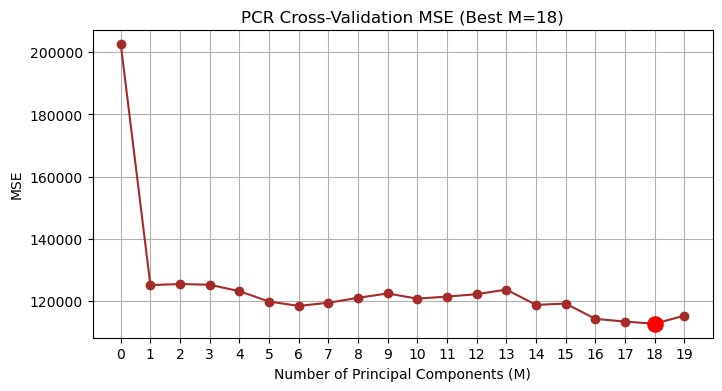

--- % Variance Explained in X ---
1 comps: 38.31%
2 comps: 60.16%
3 comps: 70.84%
4 comps: 79.03%
5 comps: 84.29%
6 comps: 88.63%


In [56]:
hitters = pd.read_csv("data/Hitters.csv").dropna()
hitters = pd.get_dummies(hitters, columns=["League", "Division", "NewLeague"], drop_first=True, dtype=int)

X = hitters.drop(columns=["Salary"]).astype(float)
y = hitters["Salary"].astype(float)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Cross-validation estimaet each amount of components
kf = KFold(n_splits=10, shuffle=True, random_state=2)
cv_mse = []

# scenario M=0
base_pred = np.full_like(y, y.mean())
cv_mse.append(mean_squared_error(y, base_pred))

# scenario from M=1 till M=19 components
for m in range(1, 20):
    pca = PCA(n_components=m)
    X_pca = pca.fit_transform(X_scaled)
    
    reg = LinearRegression()
    scores = cross_val_score(reg, X_pca, y, cv=kf, scoring="neg_mean_squared_error")
    cv_mse.append(-scores.mean())

# CV MSE as a function of amount of components
plt.figure(figsize=(8, 4))
plt.plot(range(0, 20), cv_mse, marker="o", color="brown")
best_m = np.argmin(cv_mse)
plt.scatter(best_m, cv_mse[best_m], color="red", s=120, zorder=5)
plt.title(f"PCR Cross-Validation MSE (Best M={best_m})")
plt.xlabel("Number of Principal Components (M)")
plt.ylabel("MSE")
plt.xticks(range(0, 20))
plt.grid(True)
plt.show()

full_pca = PCA().fit(X_scaled)
explained_var_X = np.cumsum(full_pca.explained_variance_ratio_) * 100

print("--- % Variance Explained in X ---")
for m_idx in range(6):
    print(f"{m_idx+1} comps: {explained_var_X[m_idx]:.2f}%")

In [57]:
np.random.seed(1)
train_indices = np.random.choice(X.index, size=len(X)//2, replace=False)
test_indices = X.index.difference(train_indices)

scaler_split = StandardScaler()
X_train_scaled = scaler_split.fit_transform(X.loc[train_indices])
X_test_scaled = scaler_split.transform(X.loc[test_indices])

y_train = y.loc[train_indices]
y_test = y.loc[test_indices]

pca_7 = PCA(n_components=7)
X_train_pca7 = pca_7.fit_transform(X_train_scaled)
X_test_pca7 = pca_7.transform(X_test_scaled)

pcr_reg = LinearRegression()
pcr_reg.fit(X_train_pca7, y_train)

preds_pcr = pcr_reg.predict(X_test_pca7)
print(f"\n[TEST PERFORMAHCE] PCR Test MSE with M=7: {mean_squared_error(y_test, preds_pcr):.2f}")


[TEST PERFORMAHCE] PCR Test MSE with M=7: 127452.69


Conclusions:
- The most significant improvement occurs after adding the first principal component (dropping MSE from ~200,000 to ~125,000). Interestingly, while the first component explains only $38.31\%$ of the variance in $X$, it clearly captures the dominant predictive signal for the target
- Certain subsequent components fail to decrease the MSE because they are constructed purely to maximize variance within $X$. Since these directions lack a meaningful relationship with the target, they introduce variance without reducing bias
- Utilizing 7 principal components yielded a competitive test MSE of 127452.69. By excluding the later noisy components, the model achieves an optimal balance, keeping variance low while maintaining a low bias

#### Task 6.7.2 Partial Least Squares

In [58]:
from sklearn.cross_decomposition import PLSRegression

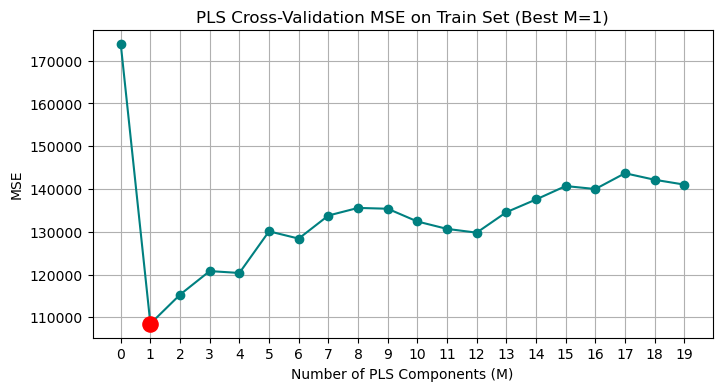


[TEST PERFORMANCE] PLS Test MSE with M=1: 133250.94


In [59]:
# We will use the exact same 50/50 split data as before
cv_mse_pls = []

# M=0 scenario (Baseline)
cv_mse_pls.append(mean_squared_error(y_train, np.full_like(y_train, y_train.mean())))

# Test M from 1 to 19 components using 10-Fold CV on the training set
kf_pls = KFold(n_splits=10, shuffle=True, random_state=1)

for m in range(1, 20):
    pls = PLSRegression(n_components=m, scale=True)
    
    # We evaluate inside the training set via cross-validation to pick best M
    scores = cross_val_score(pls, X.loc[train_indices], y_train, cv=kf_pls, scoring="neg_mean_squared_error")
    cv_mse_pls.append(-scores.mean())

best_m_pls = np.argmin(cv_mse_pls)

# Plot the PLS Cross-Validation curve
plt.figure(figsize=(8, 4))
plt.plot(range(0, 20), cv_mse_pls, marker='o', color='teal')
plt.scatter(best_m_pls, cv_mse_pls[best_m_pls], color='red', s=120, zorder=5)
plt.title(f"PLS Cross-Validation MSE on Train Set (Best M={best_m_pls})")
plt.xlabel("Number of PLS Components (M)")
plt.ylabel("MSE")
plt.xticks(range(0, 20))
plt.grid(True)
plt.show()

# Evaluate the chosen M on the Test Set
final_pls = PLSRegression(n_components=best_m_pls, scale=True)
final_pls.fit(X_train_scaled, y_train)
preds_pls = final_pls.predict(X_test_scaled)

print(f"\n[TEST PERFORMANCE] PLS Test MSE with M={best_m_pls}: {mean_squared_error(y_test, preds_pls):.2f}")

Conclusions:
- When evaluating the cross-validation error on the training set, the optimal value is reached at $M=1$. Although the final test MSE is slightly higher than PCR's best score, PLS achieves a highly competitive result using significantly fewer dimensions.
- Adding more components led to worse performance because the first component already captured the essential predictive signal. Subsequent components merely increased model flexibility, which decreased bias on training data but drastically increased variance on the test set (overfitting)
- While a single component might not capture every subtle feature interaction, it provides the best bias-variance tradeoff to avoid overfitting on this size of data

### Block Exercises

#### Task 8
In this exercise, we will generate simulated data, and will then use
this data to perform best subset selection.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [36]:
np.random.seed(42)

n = 100
# (a) create feature X and noise epsilon
X = np.random.normal(size=n)
epsilon = np.random.normal(size=n, scale=1.0)

# (b)  create Y (polynomial of degree 3)
beta_0 = 3
beta_1 = 2
beta_2 = -1.5
beta_3 = 0.8

Y = beta_0 + beta_1 * X + beta_2 * (X**2) + beta_3 * (X**3) + epsilon

data = pd.DataFrame({f'X_{i}': X**i for i in range(1, 11)})
data["Y"] = Y

print("Data shape:", data.shape)
print(data.head(3))

Data shape: (100, 11)
        X_1       X_2       X_3       X_4       X_5       X_6           X_7  \
0  0.496714  0.246725  0.122552  0.060873  0.030237  0.015019  7.460119e-03   
1 -0.138264  0.019117 -0.002643  0.000365 -0.000051  0.000007 -9.659851e-07   
2  0.647689  0.419500  0.271706  0.175981  0.113981  0.073824  4.781493e-02   

            X_8           X_9          X_10         Y  
0  3.705547e-03  1.840597e-03  9.142508e-04  2.306012  
1  1.335613e-07 -1.846675e-08  2.553293e-09  2.272036  
2  3.096918e-02  2.005838e-02  1.299158e-02  3.540776  


In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import itertools

# the function for estimating one certain combination of variables
def process_subset(feature_set):
    feature_list = list(feature_set)
    model = LinearRegression()
    model.fit(data[feature_list], Y)
    preds = model.predict(data[feature_list])
    RSS = np.sum(np.square(Y - preds))
    return {"model": model, "RSS": RSS, "features": feature_list}


# the function for searching best model within all combinations k
def get_best_of_k(k):
    # gether all features
    features = [col for col in data.columns if col != "Y"]
    
    results = []
    # trying all possible combinations k size
    for combo in itertools.combinations(features, k):
        # adding const in every single model
        results.append(process_subset(combo))

    # return the model with the minimum RSS
    df_results = pd.DataFrame(results)
    best_model = df_results.loc[df_results['RSS'].idxmin()]
    return best_model


Y_mean = np.mean(Y)
TSS = np.sum((Y - Y_mean) ** 2)
models_summary = []

# Start loop
for k in range(1, 11):
    best_for_k = get_best_of_k(k)
    rss = best_for_k["RSS"]
    d = k + 1  # weights + intercept
    
    bic = n * np.log(rss / n) + d * np.log(n)
    adj_r2 = 1 - ((rss / (n - d)) / (TSS / (n - 1)))

    models_summary.append({
        "k": k,
        "features": best_for_k['features'],
        "RSS": rss,
        "BIC": bic,
        "Adjusted_R2": adj_r2
    })
    print(f"Model with size k={k} is computed.")

df_summary = pd.DataFrame(models_summary)
print("\n--- All models are computed ---")
print(df_summary[["k", "RSS", "BIC", "Adjusted_R2"]])

Model with size k=1 is computed.
Model with size k=2 is computed.
Model with size k=3 is computed.
Model with size k=4 is computed.
Model with size k=5 is computed.
Model with size k=6 is computed.
Model with size k=7 is computed.
Model with size k=8 is computed.
Model with size k=9 is computed.
Model with size k=10 is computed.

--- All models are computed ---
    k         RSS         BIC  Adjusted_R2
0   1  384.696111  143.938692     0.850676
1   2  184.217206   74.910045     0.927757
2   3  111.000094   28.856767     0.956016
3   4  110.564966   33.069160     0.955728
4   5  107.006134   34.402619     0.956697
5   6  102.521689   34.726610     0.958066
6   7  101.791879   38.617376     0.957911
7   8  101.393590   42.830500     0.957615
8   9  101.084597   47.130459     0.957275
9  10  100.943926   51.596370     0.956855


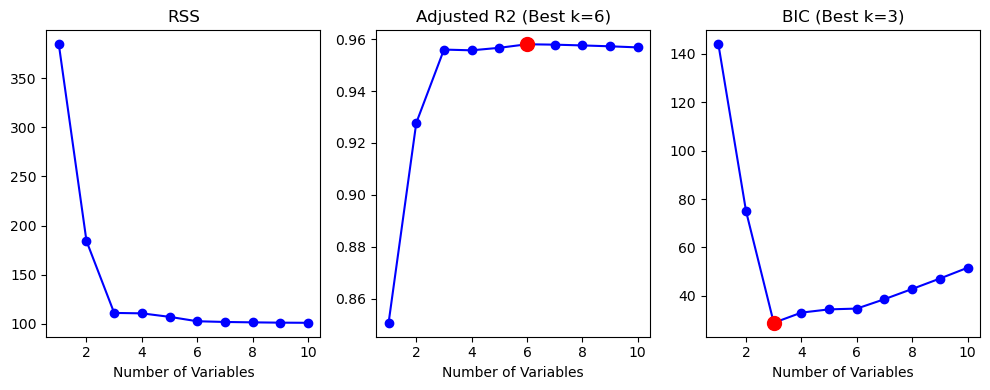

In [14]:
best_adj_r2 = df_summary.loc[df_summary["Adjusted_R2"].idxmax()]
best_bic = df_summary.loc[df_summary["BIC"].idxmin()]

fig, axes = plt.subplots(1, 3, figsize=(10, 4))

# RSS
axes[0].plot(df_summary["k"], df_summary["RSS"], marker="o", color="b")
axes[0].set_title("RSS")
axes[0].set_xlabel("Number of Variables")

# Adjusted R2
axes[1].plot(df_summary["k"], df_summary["Adjusted_R2"], marker="o", color="b")
axes[1].scatter(best_adj_r2["k"], best_adj_r2["Adjusted_R2"], color="red", s=100, zorder=5)
axes[1].set_title(f"Adjusted R2 (Best k={int(best_adj_r2['k'])})")
axes[1].set_xlabel("Number of Variables")

# BIC
axes[2].plot(df_summary["k"], df_summary["BIC"], marker="o", color="b")
axes[2].scatter(best_bic["k"], best_bic["BIC"], color="red", s=100, zorder=5)
axes[2].set_title(f"BIC (Best k={int(best_bic['k'])})")
axes[2].set_xlabel("Number of Variables")

plt.tight_layout()
plt.show()

In [20]:
df_summary.loc[2, 'features']

['X_1', 'X_2', 'X_3']

Conclusions:
- The left-hand chart confirmed the rule about RSS: "The more features we add to the model, the lower the RSS and the higher the $R^2$"
- A model should maximize Adjusted $R^2$ to be selected. In this case, the maximum Adjusted $R^2$ is 0.958 (at $k=6$)
- On the other hand, the right-hand chart demonstrates the BIC approach. A model must minimize BIC to be chosen. In this case, the lowest BIC is 28.856 (at $k=3$). This yields the correct architecture because our simulated data was generated using a polynomial of degree 3.

(d) Repeat (c), using forward stepwise selection and also using backwards stepwise selection. How does your answer compare to the
results in (c)?

In [21]:
from sklearn.feature_selection import SequentialFeatureSelector

In [23]:
X_data = data[[f"X_{i}" for i in range(1, 11)]]
X_cols = np.array([f"X_{i}" for i in range(1, 11)])

# 1. Forward selection
sfs_forward = SequentialFeatureSelector(
    LinearRegression(), 
    n_features_to_select=3, 
    direction="forward"
)
sfs_forward.fit(X_data, Y)
print("Forward Selection (k=3):", X_cols[sfs_forward.get_support()])

# 2. Backward selection
sfs_backward = SequentialFeatureSelector(
    LinearRegression(), 
    n_features_to_select=3, 
    direction="backward"
)
sfs_backward.fit(X_data, Y)
print("Backward Selection (k=3):", X_cols[sfs_backward.get_support()])

Forward Selection (k=3): ['X_1' 'X_2' 'X_3']
Backward Selection (k=3): ['X_4' 'X_5' 'X_6']


The results for the Forward Selection approach are identical to the results obtained via the Best Subsets method. At the same time, Backward Selection did not manage to capture the same combination of features

These differences stem from the nature of the algorithms. The Backward approach reduces features one at a time, starting from the full model. Consequently, there is a high probability that it mistakenly drops a relevant feature early on and cannot recover it.

On the other hand, the Forward approach adds features one by one. Given that our true underlying data structure is driven by the sequential order of $X_1, X_2, X_3$, this approach easily picked them up in sequence. However, a known disadvantage of the Forward method is that it evaluates the unique effect of each feature sequentially, potentially missing critical synergy effects between variables.

(e) Now fit a lasso model to the simulated data, again using X, X2,
...,X10 as predictors. Use cross-validation to select the optimal
value of λ. Create plots of the cross-validation error as a function
of λ. Report the resulting coefficient estimates, and discuss the
results obtained.

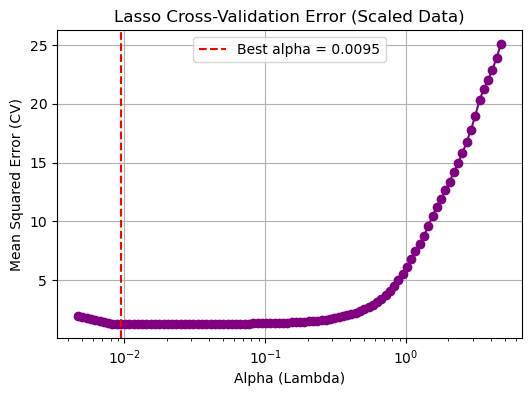

Best Alpha: 0.009462272462448825

Lasso Coefficients (on scaled features):
X_1: 2.1402
X_2: -2.0292
X_3: 1.8942
X_4: 0.3249
X_5: 0.0000
X_6: 0.0000
X_7: 0.0000
X_8: -0.0000
X_9: 0.2699
X_10: -0.0000
Intercept: 1.3084


In [25]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data[[f"X_{i}" for i in range(1, 11)]])
X_scaled_df = pd.DataFrame(X_scaled, columns=[f"X_{i}" for i in range(1, 11)])

lasso_cv = LassoCV(cv=5, random_state=42, max_iter=50000)
lasso_cv.fit(X_scaled_df, Y)

mean_mse = np.mean(lasso_cv.mse_path_, axis=1)

plt.figure(figsize=(6, 4))
plt.plot(lasso_cv.alphas_, mean_mse, marker="o", color="purple")
plt.axvline(lasso_cv.alpha_, color="red", linestyle="--", label=f"Best alpha = {lasso_cv.alpha_:.4f}")
plt.xlabel("Alpha (Lambda)")
plt.ylabel("Mean Squared Error (CV)")
plt.title("Lasso Cross-Validation Error (Scaled Data)")
plt.xscale("log")
plt.legend()
plt.grid(True)
plt.show()

print("Best Alpha:", lasso_cv.alpha_)
print("\nLasso Coefficients (on scaled features):")
for col, coef in zip(X_scaled_df.columns, lasso_cv.coef_):
    print(f"{col}: {coef:.4f}")
print(f"Intercept: {lasso_cv.intercept_:.4f}")

The Lasso approach successfully identified the primary driving features, shrinking most of the irrelevant polynomial degrees to absolute zero. Although $X^9$ (and slightly $X^4$) were not completely zeroed out, Lasso still managed to significantly reduce the overall feature space.

The optimal penalty parameter ($\alpha$) is quite small (0.0095). This subtle regularization slightly constrains the model parameters, effectively minimizing variance at the cost of a negligible increase in bias.

Aside from the minor noise captured in $X^9$, the final coefficients for the non-zero variables are distributed relatively evenly, aligning closely with the structure of our true underlying data.

(f) Now generate a response vector Y according to the model
Y = β0 + β7X7 + $\epsilon$,
and perform best subset selection and the lasso. Discuss the
results obtained

In [38]:
np.random.seed(42)

n = 100
# (a) create feature X and noise epsilon
X = np.random.normal(size=n)
epsilon = np.random.normal(size=n, scale=1.0)

# (b)  create Y
beta_0 = 3
beta_7 = 2

Y = beta_0 + beta_7 * (X**7) + epsilon

data = pd.DataFrame({f'X_{i}': X**i for i in range(1, 11)})
data["Y"] = Y

print("Data shape:", data.shape)
print(data.head(3))

Y_mean = np.mean(Y)
TSS = np.sum((Y - Y_mean) ** 2)
models_summary = []

# Start loop
for k in range(1, 11):
    best_for_k = get_best_of_k(k)
    rss = best_for_k["RSS"]
    d = k + 1  # weights + intercept
    
    bic = n * np.log(rss / n) + d * np.log(n)
    adj_r2 = 1 - ((rss / (n - d)) / (TSS / (n - 1)))

    models_summary.append({
        "k": k,
        "features": best_for_k['features'],
        "RSS": rss,
        "BIC": bic,
        "Adjusted_R2": adj_r2
    })
    print(f"Model with size k={k} is computed.")

df_summary = pd.DataFrame(models_summary)
print("\n--- All models are computed ---")
print(df_summary[["k", "RSS", "BIC", "Adjusted_R2"]])

Data shape: (100, 11)
        X_1       X_2       X_3       X_4       X_5       X_6           X_7  \
0  0.496714  0.246725  0.122552  0.060873  0.030237  0.015019  7.460119e-03   
1 -0.138264  0.019117 -0.002643  0.000365 -0.000051  0.000007 -9.659851e-07   
2  0.647689  0.419500  0.271706  0.175981  0.113981  0.073824  4.781493e-02   

            X_8           X_9          X_10         Y  
0  3.705547e-03  1.840597e-03  9.142508e-04  1.599549  
1  1.335613e-07 -1.846675e-08  2.553293e-09  2.579353  
2  3.096918e-02  2.005838e-02  1.299158e-02  2.752915  
Model with size k=1 is computed.
Model with size k=2 is computed.
Model with size k=3 is computed.
Model with size k=4 is computed.
Model with size k=5 is computed.
Model with size k=6 is computed.
Model with size k=7 is computed.
Model with size k=8 is computed.
Model with size k=9 is computed.
Model with size k=10 is computed.

--- All models are computed ---
    k        RSS        BIC  Adjusted_R2
0   1  89.333780  -2.068708     

In [40]:
df_summary.loc[1, 'features']

['X_2', 'X_7']

Due to the extreme scale of the 7th power ($X^7$), the signal-to-noise ratio in this simulation is exceptionally high, which is reflected in an Adjusted $R^2$ of nearly 0.9999 across all dimensions.

The BIC criterion reaches its global minimum at $k=2$ ($\text{BIC} = -3.389$), slightly overestimating the true model size ($k=1$).

This happens because, without prior standardization, the linear regression leverages a second feature to slightly adjust and overfit the remaining noise, leading to a minor drop in RSS (from 89.33 to 84.19) that outweighs the BIC penalty. However, the true driving force ($X^7$) is successfully captured by the algorithm from the very first step

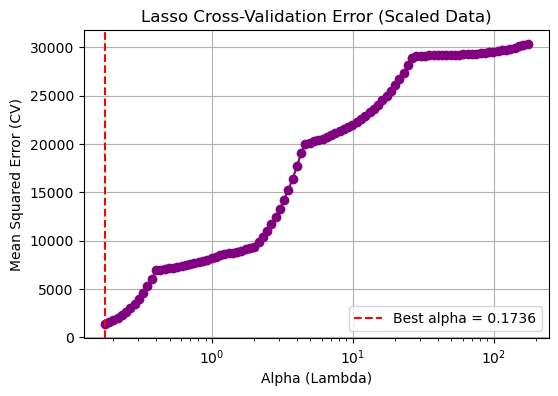

Best Alpha: 0.1735813815707066

Lasso Coefficients (on scaled features):
X_1: -0.0000
X_2: -0.0000
X_3: 0.0000
X_4: -0.0000
X_5: 10.8061
X_6: -0.2231
X_7: 140.8199
X_8: -0.0000
X_9: 22.0059
X_10: -0.0000
Intercept: -19.8077


In [41]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data[[f"X_{i}" for i in range(1, 11)]])
X_scaled_df = pd.DataFrame(X_scaled, columns=[f"X_{i}" for i in range(1, 11)])

lasso_cv = LassoCV(cv=5, random_state=42, max_iter=50000)
lasso_cv.fit(X_scaled_df, Y)

mean_mse = np.mean(lasso_cv.mse_path_, axis=1)

plt.figure(figsize=(6, 4))
plt.plot(lasso_cv.alphas_, mean_mse, marker="o", color="purple")
plt.axvline(lasso_cv.alpha_, color="red", linestyle="--", label=f"Best alpha = {lasso_cv.alpha_:.4f}")
plt.xlabel("Alpha (Lambda)")
plt.ylabel("Mean Squared Error (CV)")
plt.title("Lasso Cross-Validation Error (Scaled Data)")
plt.xscale("log")
plt.legend()
plt.grid(True)
plt.show()

print("Best Alpha:", lasso_cv.alpha_)
print("\nLasso Coefficients (on scaled features):")
for col, coef in zip(X_scaled_df.columns, lasso_cv.coef_):
    print(f"{col}: {coef:.4f}")
print(f"Intercept: {lasso_cv.intercept_:.4f}")

After standardization, all features are placed on the same scale, allowing Lasso to distribute weights based on statistical contribution rather than variance magnitude

While $X^7$ remains the absolute dominant predictor with a massive coefficient of 140.82, Lasso also retains non-zero weights for other odd powers, specifically $X^5$ and $X^9$.

This behavior is a direct consequence of high polynomial multicollinearity. Because odd powers ($X^5, X^7, X^9$) share a highly similar functional shape, the model combines them to subtly adjust the regression curve and overfit the remaining random noise $\epsilon$ on the training set. Meanwhile, even powers are correctly shrunken to zero due to their mismatched symmetry

#### Task 9
In this exercise, we will predict the number of applications received
using the other variables in the College data setn

In [42]:
from sklearn.model_selection import train_test_split

college = pd.read_csv("data/College.csv")

college.rename(columns={"Unnamed: 0": "College"}, inplace=True)
college.set_index("College", inplace=True)

college["Private"] = college["Private"].map({"Yes": 1, "No": 0})

X = college.drop("Apps", axis=1)
y = college["Apps"]

# a) Split data on train/test

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=X.columns)
X_test = pd.DataFrame(scaler.transform(X_test_raw), columns=X.columns)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (582, 17), Test shape: (195, 17)


(b) Fit a linear model using least squares on the training set, and
report the test error obtained.

In [44]:
from sklearn.metrics import mean_squared_error

ols_model = LinearRegression()
ols_model.fit(X_train, y_train)

ols_preds = ols_model.predict(X_test)
ols_mse = mean_squared_error(y_test, ols_preds)

print(f"(b) OLS Test MSE: {ols_mse:.2f}")

(b) OLS Test MSE: 1817982.65


(c) Fit a ridge regression model on the training set, with λ chosen
by cross-validation. Report the test error obtained.

In [49]:
from sklearn.linear_model import RidgeCV

alphas = np.logspace(-3, 3, 100)

ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train, y_train)

ridge_preds = ridge_cv.predict(X_test)
ridge_mse = mean_squared_error(y_test, ridge_preds)

print(f"(c) Ridge Best Alpha: {ridge_cv.alpha_:.4f}")
print(f"Ridge Test MSE: {ridge_mse:.2f}")

(c) Ridge Best Alpha: 0.0010
Ridge Test MSE: 1817954.90


(d) Fit a lasso model on the training set, with λ chosen by cross-validation. Report the test error obtained, along with the number of non-zero coefficient estimates.

In [50]:
from sklearn.linear_model import LassoCV

lasso_cv = LassoCV(cv=5, max_iter=50000, random_state=42)
lasso_cv.fit(X_train, y_train)

lasso_preds = lasso_cv.predict(X_test)
lasso_mse = mean_squared_error(y_test, lasso_preds)

non_zero_coefficients = np.sum(lasso_cv.coef_ != 0)

print(f"(d) Lasso Best Alpha: {lasso_cv.alpha_:.4f}")
print(f"Lasso Test MSE: {lasso_mse:.2f}")
print(f"Number of non-zero coefficients: {non_zero_coefficients} out of {X_train.shape[1]}")

(d) Lasso Best Alpha: 3.7740
Lasso Test MSE: 1801154.20
Number of non-zero coefficients: 16 out of 17


Conclusions:
- Ordinary Least Squares reached a test MSE of 1,817,982.65
- Ridge regression yielded a test MSE of 1817954.90 (nearly identical to OLS). The optimal penalty parameter is very small ($\lambda = 0.0010$), meaning the model is barely constrained; its variance remains high, while its bias is low.
- Lasso regression achieved a slightly better test MSE of 1801154.20. The optimal penalty is moderately higher ($\lambda = 3.7740$), imposing a stronger constraint than Ridge. However, it only eliminated 1 out of 17 features, meaning variance is still relatively high, and bias remains small.

In [51]:
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)
pcr_cv_errors = []

for m in range(1, 18):
    pca = PCA(n_components=m)
    X_train_pca = pca.fit_transform(X_train)
    
    model = LinearRegression()
    scores = cross_val_score(model, X_train_pca, y_train, cv=kf, scoring="neg_mean_squared_error")
    pcr_cv_errors.append(-np.mean(scores))

best_m_pcr = np.argmin(pcr_cv_errors) + 1

pca_final = PCA(n_components=best_m_pcr)
X_train_pcr = pca_final.fit_transform(X_train)
X_test_pcr = pca_final.transform(X_test)

pcr_model = LinearRegression()
pcr_model.fit(X_train_pcr, y_train)
pcr_preds = pcr_model.predict(X_test_pcr)
pcr_mse = mean_squared_error(y_test, pcr_preds)

print(f"(e) PCR Best M (components): {best_m_pcr}")
print(f"PCR Test MSE: {pcr_mse:.2f}")

(e) PCR Best M (components): 17
PCR Test MSE: 1817982.65


In [53]:
from sklearn.cross_decomposition import PLSRegression

pls_cv_errors = []

for m in range(1, 18):
    pls = PLSRegression(n_components=m)
    scores = cross_val_score(pls, X_train, y_train, cv=kf, scoring="neg_mean_squared_error")
    pls_cv_errors.append(-np.mean(scores))

best_m_pls = np.argmin(pls_cv_errors) + 1

pls_final = PLSRegression(n_components=best_m_pls)
pls_final.fit(X_train, y_train)
pls_preds = pls_final.predict(X_test)
pls_mse = mean_squared_error(y_test, pls_preds)

print(f"(f) PLS Best M (components): {best_m_pls}")
print(f"PLS Test MSE: {pls_mse:.2f}")

(f) PLS Best M (components): 17
PLS Test MSE: 1817982.65


Both PCR and PLS selected the maximum number of components ($M = 17$), resulting in a test MSE of 1,817,982.65, which is exactly identical to the Ordinary Least Squares (OLS) model.

The fact that dimension reduction techniques preferred the full feature space indicates that there is no structural redundancy or heavy multicollinearity in the College dataset. Every single variable contributes unique, non-overlapping information to explain the target variable.

Looking at all five approaches, the test errors are remarkably close, ranging from 1,801,154.20 (Lasso) to 1,817,982.65 (OLS, PCR, PLS). Lasso performed slightly better by optimizing the weights of the 16 most predictive features and shrinking the remaining one.

Overall, we can predict the number of college applications with high accuracy (given the high baseline variance of Apps). Since linear constraints combined with slight regularization (Lasso) yield the best performance, the underlying relationships are predominantly linear, and moving to highly flexible non-linear models is not strictly necessary unless capturing minor local fluctuations

#### Task 10

We have seen that as the number of features used in a model increases,
the training error will necessarily decrease, but the test error may not.
We will now explore this in a simulated data set

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import itertools

In [6]:
np.random.seed(42)

n = 1000
p = 10

# (a) generate X
X = np.random.normal(size=(n, p))
feature_names = [f"X_{i}" for i in range(1, p + 1)]
df_X = pd.DataFrame(X, columns=feature_names)

# generate beta
true_beta = np.zeros(p)
true_beta[0] = 3.4
true_beta[1] = -2.5
true_beta[2] = 1.2

# epsilon
epsilon = np.random.normal(scale=1.0, size=n)

Y = np.dot(X, true_beta) + epsilon

# (b) split train test data
X_train = df_X.iloc[:100].reset_index(drop=True)
y_train = Y[:100]

X_test = df_X.iloc[100:].reset_index(drop=True)
y_test = Y[100:]

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 100, Test size: 900


(c) Perform best subset selection on the training set, and plot the
training set MSE associated with the best model of each size.

(d) Plot the test set MSE associated with the best model of each
size.

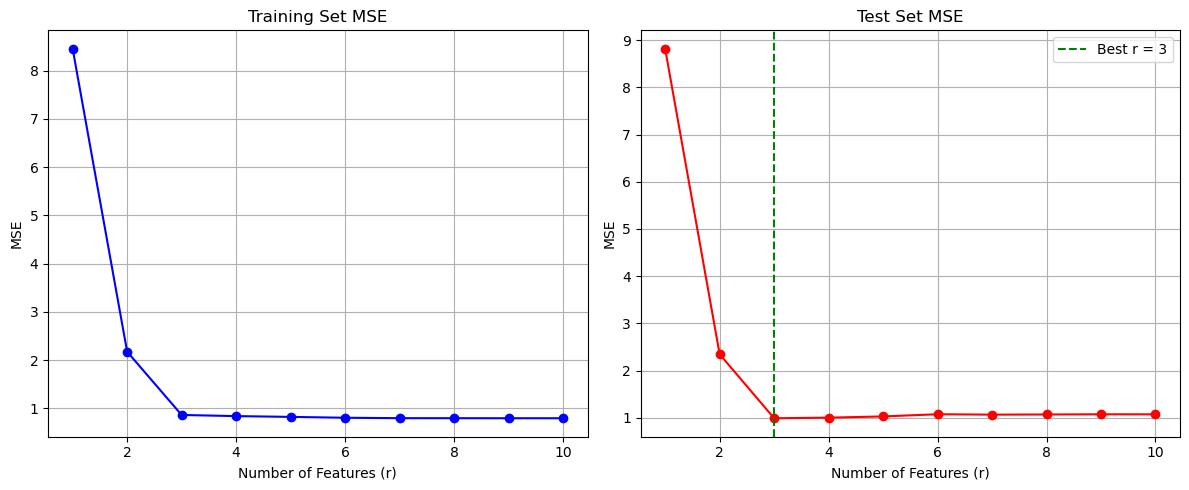

In [7]:
def process_subset(feature_set):
    model = LinearRegression()
    model.fit(X_train[list(feature_set)], y_train)
    
    train_preds = model.predict(X_train[list(feature_set)])
    train_mse = mean_squared_error(y_train, train_preds)
    return {"train_mse": train_mse, "features": list(feature_set)}

best_models = {}


for r in range(1, p + 1):
    results = []
    for combo in itertools.combinations(feature_names, r):
        results.append(process_subset(combo))
        
    df_results = pd.DataFrame(results)
    best_models[r] = df_results.loc[df_results['train_mse'].idxmin()]


records = []
for r in range(1, p + 1):
    best_features = best_models[r]["features"]
    train_mse = best_models[r]["train_mse"]
    
    model = LinearRegression()
    model.fit(X_train[best_features], y_train)
    test_preds = model.predict(X_test[best_features])
    test_mse = mean_squared_error(y_test, test_preds)
    
    records.append({
        "r": r,
        "train_mse": train_mse,
        "test_mse": test_mse,
        "features": best_features
    })

df_summary = pd.DataFrame(records)


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(df_summary["r"], df_summary["train_mse"], marker="o", color="blue")
plt.xlabel("Number of Features (r)")
plt.ylabel("MSE")
plt.title("Training Set MSE")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(df_summary["r"], df_summary["test_mse"], marker="o", color="red")
best_r_test = df_summary.loc[df_summary["test_mse"].idxmin(), "r"]
plt.axvline(best_r_test, color="green", linestyle="--", label=f"Best r = {best_r_test}")
plt.xlabel("Number of Features (r)")
plt.ylabel("MSE")
plt.title("Test Set MSE")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Train MSE decreased steadily as we add new feature

Test MSE fluctuated forming U-shape curve.

Best test MSE was reached on r = 3 (3 features was selected). It makes sence so we created only three useful variables, others are noise

(f) How does the model at which the test set MSE is minimized
compare to the true model used to generate the data? Comment
on the coefficient values.

--- (f) Comparing coefficients ---
Chosen features: ['X_1', 'X_2', 'X_3']

X_1 | True weight:  3.4 | estimated weight: 3.2587
X_2 | True weight: -2.5 | estimated weight: -2.5149
X_3 | True weight:  1.2 | estimated weight: 1.1284
X_4 | True weight:  0.0 | estimated weight: 0.0000
X_5 | True weight:  0.0 | estimated weight: 0.0000
X_6 | True weight:  0.0 | estimated weight: 0.0000
X_7 | True weight:  0.0 | estimated weight: 0.0000
X_8 | True weight:  0.0 | estimated weight: 0.0000
X_9 | True weight:  0.0 | estimated weight: 0.0000
X_10 | True weight:  0.0 | estimated weight: 0.0000


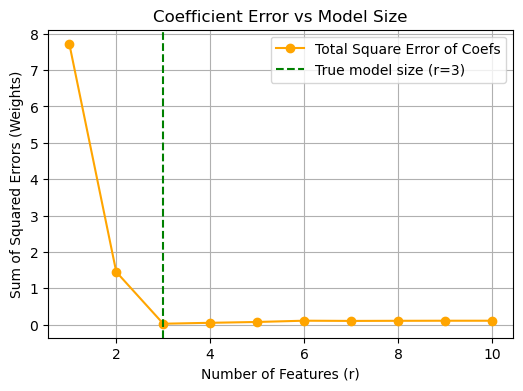

In [8]:
best_features_r3 = df_summary.loc[df_summary["r"] == 3, "features"].values[0]

model_r3 = LinearRegression()
model_r3.fit(X_train[best_features_r3], y_train)

print("--- (f) Comparing coefficients ---")
print(f"Chosen features: {best_features_r3}\n")
for i, name in enumerate(feature_names):
    estimated_coef = 0.0
    if name in best_features_r3:
        
        idx = best_features_r3.index(name)
        estimated_coef = model_r3.coef_[idx]
    print(f"{name} | True weight: {true_beta[i]:4.1f} | estimated weight: {estimated_coef:.4f}")

# (g)
beta_errors = []

for r in range(1, p + 1):
    best_features = df_summary.loc[df_summary["r"] == r, "features"].values[0]
    
    model_r = LinearRegression()
    model_r.fit(X_train[best_features], y_train)
    
    estimated_beta = np.zeros(p)
    for i, name in enumerate(feature_names):
        if name in best_features:
            idx = best_features.index(name)
            estimated_beta[i] = model_r.coef_[idx]
            
    sum_sq_beta_error = np.sum((true_beta - estimated_beta) ** 2)
    beta_errors.append(sum_sq_beta_error)

plt.figure(figsize=(6, 4))
plt.plot(df_summary["r"], beta_errors, marker="o", color="orange", label="Total Square Error of Coefs")
plt.axvline(3, color="green", linestyle="--", label="True model size (r=3)")
plt.xlabel("Number of Features (r)")
plt.ylabel("Sum of Squared Errors (Weights)")
plt.title("Coefficient Error vs Model Size")
plt.legend()
plt.grid(True)
plt.show()

For the optimal model size $r = 3$, Best Subset Selection accurately identified the true underlying feature space ['X_1', 'X_2', 'X_3']. The estimated coefficients match the true weights closely, with minor variations directly caused by the random irreducible noise ($\epsilon$) present in the training set

The Test MSE curve and the Coefficient Error (Squared Distance) chart exhibit an identical behavior. Both metrics achieve their global minimum at exactly $r = 3$.

When the model size $r > 3$, the test error metrics begin to slightly increase. While the model utilizes extra features to fit the random variance of the training set (lowering Train MSE), it moves farther away from the true parameters $\beta$, leading to poorer generalization on the unseen test data

#### Task 11

We will now try to predict per capita crime rate in the Boston data
set